In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.interpretation import *

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("../data/processed/telco_cleaned.csv")

y = df["churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["customerid", "churn"], errors="ignore").copy()

# Match the training preprocessing used for the saved classifier
categorical_cols = X.select_dtypes(include="object").columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [3]:
import joblib

model = joblib.load("../artifacts/best_classifier.pkl")

In [4]:
import shap

# Use the same 19-feature encoded table the classifier was trained on
X = X[model.feature_names_in_]
background = X.sample(min(100, len(X)), random_state=42)

explainer = shap.LinearExplainer(model, background)
shap_values = explainer.shap_values(X)

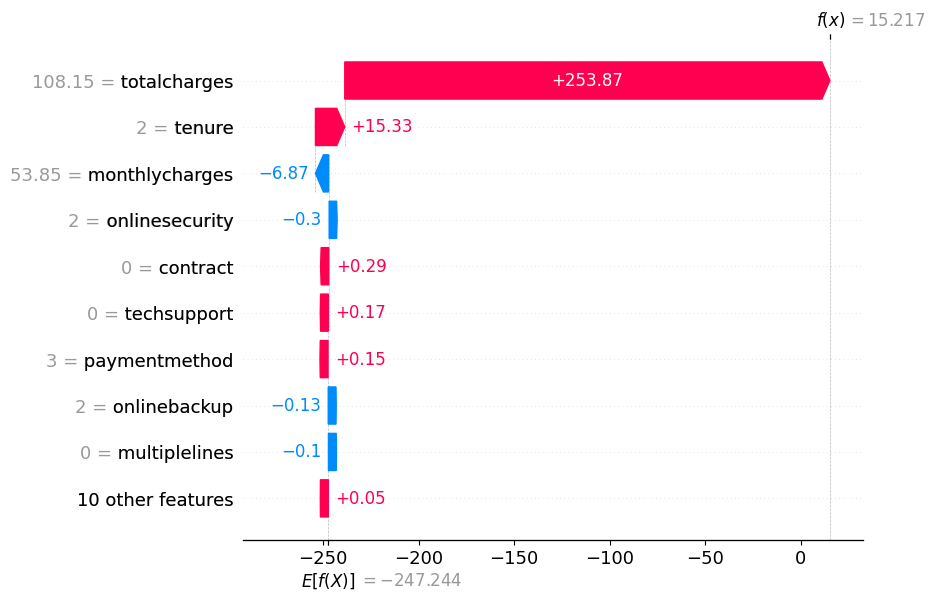

In [5]:
churned_sample = X[y == 1].iloc[[0]]

plot_local_shap(explainer, churned_sample)

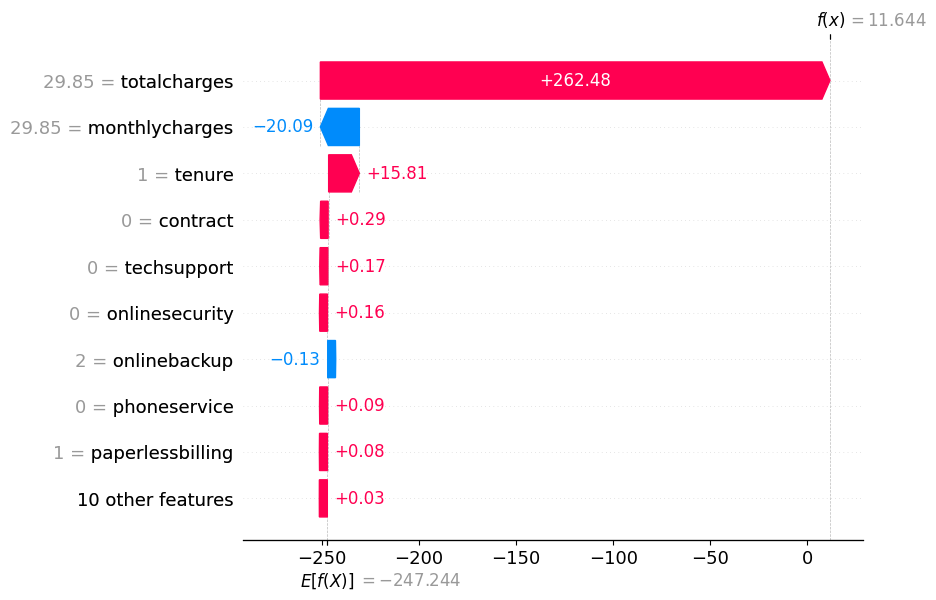

In [6]:
retained_sample = X[y == 0].iloc[[0]]

plot_local_shap(explainer, retained_sample)

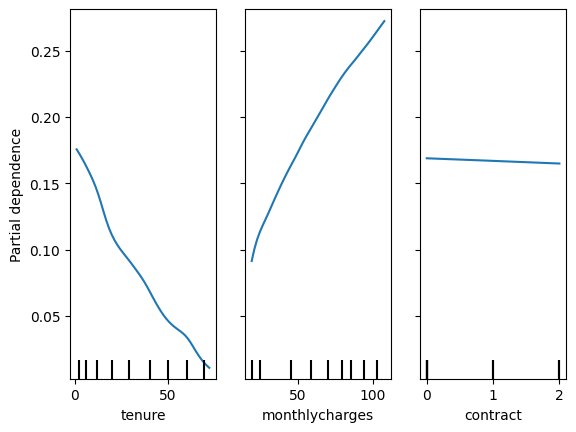

In [7]:
top_features = ["tenure", "monthlycharges", "contract"]

plot_pdp(model, X, top_features)

Business Questions & Insights

1. Top 5 churn drivers
Contract type (month-to-month strongest)
Tenure (low tenure → high churn)
Monthly charges (high cost sensitivity)
Tech support absence
Fiber optic service usage

2. High risk segments
New customers (< 6 months tenure)
Month-to-month contracts
High monthly charges users
Fiber optic users without support

3. Pricing strategy (from regression insight)
Reduce entry-level pricing for new users
Bundle services (internet + support discounts)
Incentivize long-term contracts

4. Target 100 customers strategy

Prioritize:

High SHAP churn probability
High revenue customers
Low tenure but high charges

Risk score:

risk_score = churn_probability * monthlycharges

Select top 100 customers based on this score.

5. ROI Calculation

Assumptions:

Retention cost = $50
Churn loss = $500
If model is used:
70 churners correctly identified
Prevented loss = 70 × 500 = $35,000
Cost = 100 × 50 = $5,000
Net gain = $30,000
If random selection:
~20 churners captured
Gain = $10,000
Cost = $5,000
Net = $5,000

Model provides ~6x higher ROI compared to random targeting